# Vanlia Neural Style Transfer

For Submission for Computer Vision Spring 2023.
This section uses neural style transfer method from https://arxiv.org/pdf/1508.06576.pdf.

Baseline code adapted from 

https://www.tensorflow.org/tutorials/generative/style_transfer

Upload Content.jpg and Style.jpg to google colab and run.

In [ ]:
import os
import tensorflow as tf
# Load compressed models from tensorflow_hub
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'


import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12, 12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import PIL.Image
import time
import functools

In [ ]:
def tensor_to_image(tensor):
  tensor = tensor*255
  tensor = np.array(tensor, dtype=np.uint8)
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

In [ ]:
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]
  return img

In [ ]:
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)

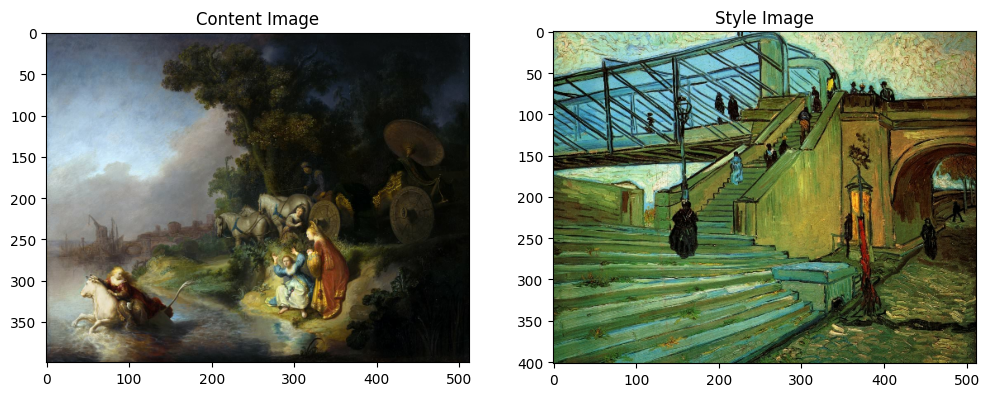

In [ ]:
content_path = '/content/Content.jpg'
style_path = '/content/Style.jpg'
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

VGG 19 Load


In [ ]:
x = tf.keras.applications.vgg19.preprocess_input(content_image*255)
x = tf.image.resize(x, (224, 224))
vgg = tf.keras.applications.VGG19(include_top=True, weights='imagenet')
prediction_probabilities = vgg(x)
prediction_probabilities.shape

574710816/574710816 [==============================] - 26s 0us/step


TensorShape([1, 1000])

In [ ]:
#Get Slices

content_layers = ['block5_conv2'] 

style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1', 
                'block4_conv1', 
                'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

In [ ]:
def vgg_layers(layer_names):
  vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
  vgg.trainable = False
  
  outputs = [vgg.get_layer(name).output for name in layer_names]

  model = tf.keras.Model([vgg.input], outputs)
  return model

In [ ]:
style_extractor = vgg_layers(style_layers)

80134624/80134624 [==============================] - 3s 0us/step


Gram Matrix Calculation

In [ ]:
def gram_matrix(input_tensor):
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
  input_shape = tf.shape(input_tensor)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
  return result/(num_locations)

In [ ]:
class StyleContentModel(tf.keras.models.Model):
  def __init__(self, style_layers, content_layers):
    super(StyleContentModel, self).__init__()
    self.vgg = vgg_layers(style_layers + content_layers)
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.num_style_layers = len(style_layers)
    self.vgg.trainable = False

  def call(self, inputs):
    "Expects float input in [0,1]"
    inputs = inputs*255.0
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
    outputs = self.vgg(preprocessed_input)
    style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                      outputs[self.num_style_layers:])

    style_outputs = [gram_matrix(style_output)
                     for style_output in style_outputs]

    content_dict = {content_name: value
                    for content_name, value
                    in zip(self.content_layers, content_outputs)}

    style_dict = {style_name: value
                  for style_name, value
                  in zip(self.style_layers, style_outputs)}

    return {'content': content_dict, 'style': style_dict}

In [ ]:
extractor = StyleContentModel(style_layers, content_layers)

In [ ]:
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

image = tf.Variable(content_image)


In [ ]:
def clip_0_1(image):
  return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

In [ ]:
# Hyperparameter weight list. Change as needed
style_weight= [1e-2]
content_weight=[1e4]

In [ ]:
def style_content_loss(outputs, s=0, c=0):
    style_outputs = outputs['style']
    content_outputs = outputs['content']
    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2) 
                           for name in style_outputs.keys()])
    style_loss *= style_weight[s] / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2) 
                             for name in content_outputs.keys()])
    content_loss *= content_weight[c] / num_content_layers

    loss = style_loss + content_loss
    return loss

In [ ]:
@tf.function()
def train_step(image, s=0, c=0):
  with tf.GradientTape() as tape:
    outputs = extractor(image)
    loss = style_content_loss(outputs, s, c)

  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))


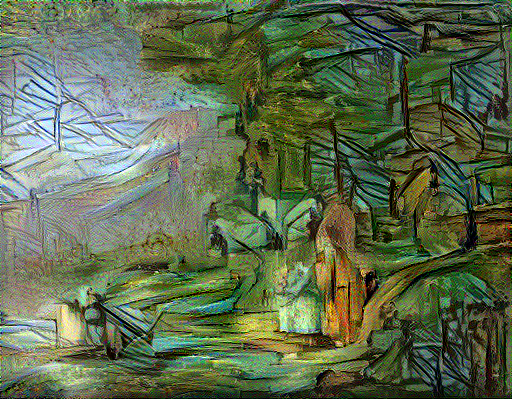

Train step: 1000


In [ ]:
#training
epochs = 10
steps_per_epoch = 100

loss_list = []

for s_i in range(len(style_weight)):
    for c_i in range(len(content_weight)):
        step = 0
        image = tf.Variable(content_image)
        opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)
        opt.build([image])
        loss_record = []

        for n in range(epochs):
            for m in range(steps_per_epoch):
                step += 1
                train_step(image, s_i, c_i)
                print(".", end='', flush=True)
            display.clear_output(wait=True)
            display.display(tensor_to_image(image))    
            print("Train step: {}".format(step))
            loss_record.append(style_content_loss(extractor(image), s_i, c_i))
        
        loss_list.append(loss_record)

# Additional Loss Section

In [ ]:
# Average Filter for image. Smoothes output
def average_filter(image, window_size):
    image = tf.squeeze(image, axis=[0])
    channels = image.shape[-1]
    image = tf.expand_dims(image, axis=0)  # Add batch dimension
    image = tf.reshape(image, [1, image.shape[1], image.shape[2], channels, 1])
    output_image = tf.nn.avg_pool3d(
        image,
        ksize=[1, window_size, window_size, 1, 1],
        strides=[1, 1, 1, 1, 1],
        padding='SAME',
        data_format='NDHWC'
    )
    return tf.reshape(output_image, [1, image.shape[1], image.shape[2], channels])

content_image_average_filter = average_filter(content_image, 3)

In [ ]:
# Edge Detection
def high_pass_x_y(image):
  x_var = image[:, :, 1:, :] - image[:, :, :-1, :]
  y_var = image[:, 1:, :, :] - image[:, :-1, :, :]

  return x_var, y_var


# Edge Detection Loss
def edge_loss(image):
    content_x_deltas, content_y_deltas = high_pass_x_y(content_image)
    x_deltas, y_deltas = high_pass_x_y(image)
    diff_x = content_x_deltas - x_deltas
    diff_y = content_y_deltas - y_deltas
    return tf.reduce_sum(tf.abs(diff_x)) + tf.reduce_sum(tf.abs(diff_y))

def edge_loss_average_filter(image):
    content_x_deltas, content_y_deltas = high_pass_x_y(content_image)
    x_deltas, y_deltas = high_pass_x_y(image)
    content_x_deltas = average_filter(content_x_deltas, 3)
    content_y_deltas = average_filter(content_y_deltas, 3)
    x_deltas = average_filter(x_deltas, 3)
    y_deltas = average_filter(y_deltas, 3)
    diff_x = content_x_deltas - x_deltas
    diff_y = content_y_deltas - y_deltas
    return tf.reduce_sum(tf.abs(diff_x)) + tf.reduce_sum(tf.abs(diff_y))
 

In [ ]:
def square_pixel_diff(image):
    return tf.reduce_sum(tf.math.square((content_image - image)))

def smoothed_square_pixel_diff(image):
    averaged_image = average_filter(image, 3)
    diff = tf.reduce_sum(tf.math.square((content_image_average_filter - averaged_image)))
    return diff

def average_pixel_diff(image):
    diff = tf.reduce_sum(tf.abs(content_image- image))
    return diff

def smoothed_average_pixel_diff(image):
    averaged_image = average_filter(image, 3)
    diff = tf.reduce_sum(tf.abs(content_image_average_filter - averaged_image))
    return diff


In [ ]:
print(square_pixel_diff(image))
print(average_pixel_diff(image))
print(edge_loss(image))
print(edge_loss_average_filter(image))


tf.Tensor(16771.027, shape=(), dtype=float32)
tf.Tensor(79424.1, shape=(), dtype=float32)
tf.Tensor(58795.8, shape=(), dtype=float32)
tf.Tensor(30276.164, shape=(), dtype=float32)


Training on








In [ ]:
# Suggested Loss Weights. Feel Free to change these for wanted effect.

# list of style, content weights. The loop below runs permutation of these two values
style_weight= [1e-2]
content_weight=[1e4]

#Suggested weights. For an image with high content image features, set weight to 3000 or higher.
#average_pixel_diff_weight = 30
average_pixel_diff_weight = 3000
square_pixel_diff_weight = 5000
total_variation_weight = 40
edge_loss_weight = 50

In [ ]:
# comment / uncomment for added loss.

@tf.function()
def train_step(image, s=0, c=0):
  with tf.GradientTape() as tape:
    outputs = extractor(image)
    loss = style_content_loss(outputs)
    #loss += square_pixel_diff_weight * square_pixel_diff(image)
    #loss += square_pixel_diff_weight * smoothed_square_pixel_diff(image)
    #loss += total_variation_weight * tf.image.total_variation(image)
    #loss += edge_loss_weight * edge_loss_average_filter(image)
    loss += average_pixel_diff_weight*average_pixel_diff(image)
    #loss += average_pixel_diff_weight*smoothed_average_pixel_diff(image)
    
  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))

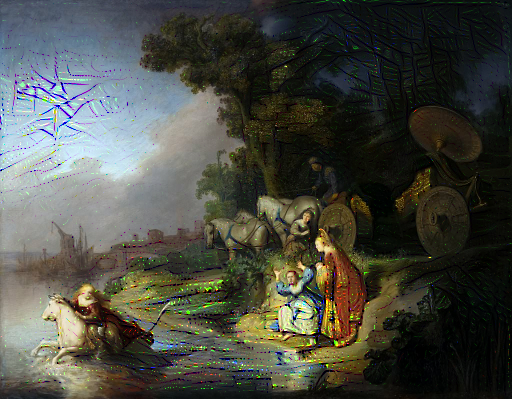

Train step: 1000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
epochs = 10
steps_per_epoch = 100

for s_i in range(len(style_weight)):
    for c_i in range(len(content_weight)):
        step = 0
        image = tf.Variable(content_image)
        opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)
        opt.build([image])
        for n in range(epochs):
            for m in range(steps_per_epoch):
                step += 1
                train_step(image, s_i, c_i)
                print(".", end='', flush=True)
            display.clear_output(wait=True)
            display.display(tensor_to_image(image))    
            print("Train step: {}".format(step))


        # Save image if needed.
        # file_name = 's_'+str(style_weight[s_i])+'c_'+str(content_weight[c_i])+'name'.png'
        # tensor_to_image(image).save(file_name)
        # try:
        #     from google.colab import files
        # except ImportError:
        #     pass
        # else:
        #     files.download(file_name) 


Processing Pipeline

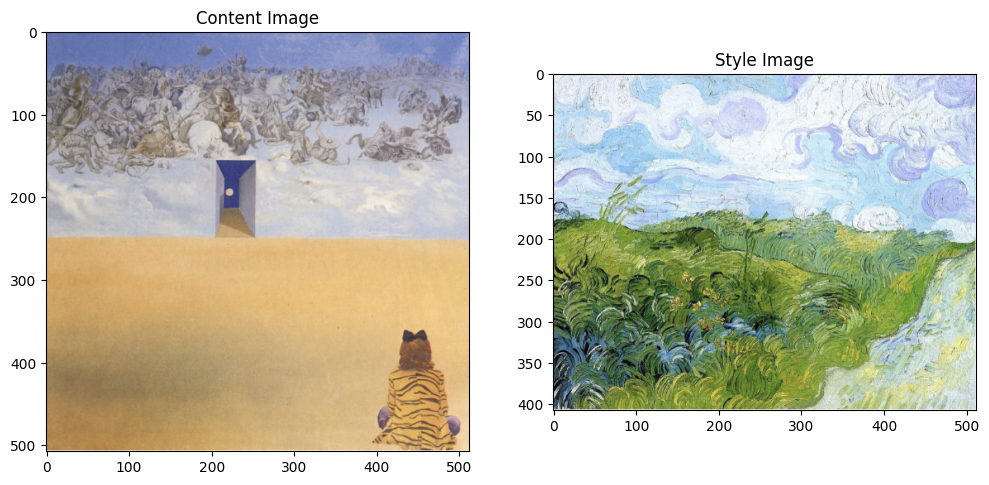

In [ ]:
content_image = load_img("Pipeline_Content.png")
style_image = load_img("Pipeline_Style.png")

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

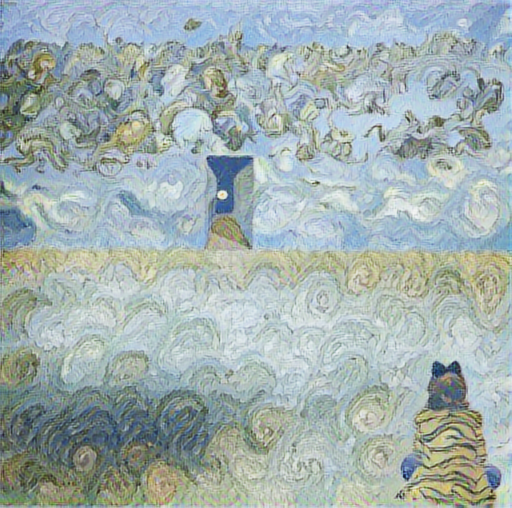

In [ ]:
import tensorflow_hub as hub
 # For ease, in this case, use the model provided by tensorflow as a demo. We can use our own model
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'). 
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]
tensor_to_image(stylized_image)

In [ ]:
file_name = 'first_stage_pipeline.png'
tensor_to_image(stylized_image).save(file_name)

try:
  from google.colab import files
except ImportError:
   pass
else:
  files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

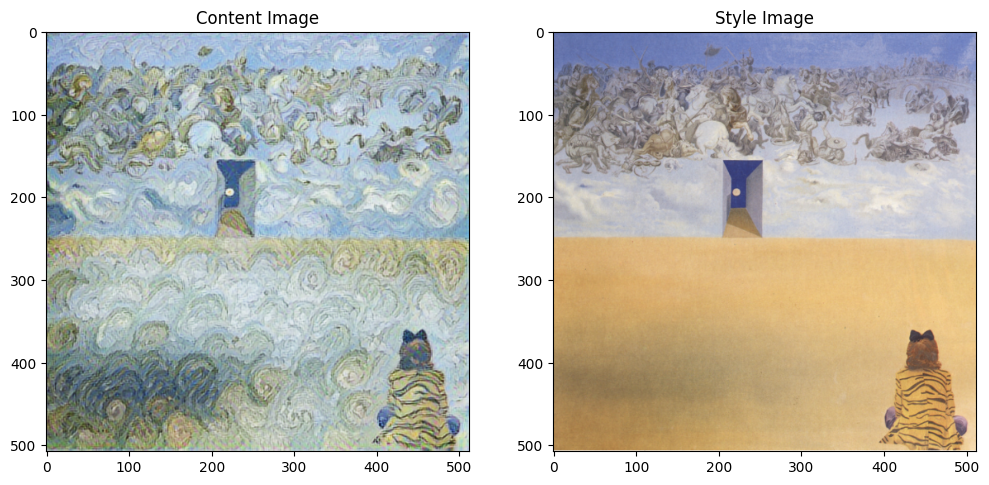

In [ ]:
content_image = load_img("first_stage_pipeline.png")
style_image = load_img("Pipeline_Content.png")

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

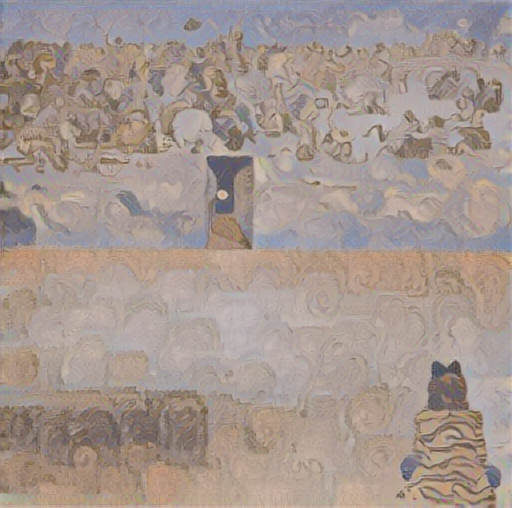

In [ ]:
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]
tensor_to_image(stylized_image)